# Upper-Expectation Nulls: Testing Against a *Set* of Distributions

## Demonstrates anytime-valid testing when the null hypothesis is a convex set of laws:
- The numeraire (GRO) e-variable for a set-valued null, and its certificate
- Wasserstein balls: a tolerance on how far Reality may drift before we care
- An anytime-valid lower confidence bound on the size of the drift
- Contamination (Huber-Strassen) neighbourhoods: valid under a known rate of corrupted records
- Polytope nulls: is the stream still a mixture of known regimes?
- Per-round announcements: a Forecaster whose set changes every round
- Type-I error validity when Reality sits exactly on the boundary of the set
- Real-world: clinical non-inferiority on an adverse-event severity scale
- Real-world: supplier quality under a known rate of mislabelled records
- Real-world: LLM judge-score regression gate in production
- Real-world: a prediction market quoting a bid-ask spread
- Physics: a Bell/CHSH experiment against *every* local-realist model at once

A classical sequential test needs a single null distribution. Many real nulls are
not single laws: "no worse than the control by more than a tolerance", "the vendor's
stated defect rate, allowing 3% mislabelled records", "some mixture of the regimes we
already understand", "any local hidden-variable theory". Each round Forecaster
announces a convex set, Skeptic buys a payoff that is a valid e-variable against
*every* member of that set simultaneously, and the capital process is an e-process
for the whole composite null.

**How the simulations are set up.** Ordinal outcomes come from a latent variable cut into
bands by the scale's own cutpoints, so a shift in the population produces whatever
probability vector and whatever Wasserstein distance it produces - none of those vectors
is chosen by hand. Contaminated records are genuinely injected at the stated rate rather
than assumed away, the polytope null faces a population whose regime blend is redrawn
every round, and the market's quotes follow a random walk. Where a section claims
something is detected, the claim is backed by replications rather than one seed.

References:
    Larsson, Ramdas & Ruf (2025). The numeraire e-variable and reverse information
    projection. Annals of Statistics. arXiv:2402.18810.
    - Definition 2.1: the numeraire e-variable of a convex set of laws
    - Theorem 2.6: existence and uniqueness
    - Theorem 3.6: the numeraire is the growth-rate optimal (GRO) e-variable
    Larsson, Ramdas & Ruf (2025). Constraint-generated composite nulls. arXiv:2504.02974.
    Grunwald, de Heide & Koolen (2024). Safe Testing. JRSS-B, Theorem 1 (GRO e-variables).
    Huber & Strassen (1973). Minimax tests and the Neyman-Pearson lemma for capacities.
    Annals of Statistics 1(2), 251-263 - least-favourable pair for contamination.
    Villani (2009). Optimal Transport: Old and New, Ch. 6 - W1 and Kantorovich duality.
    Shafer & Vovk (2019). Game-Theoretic Foundations for Probability and Finance, Ch. 1, 8.
    Ramdas & Wang (2025). Hypothesis testing with e-values, Ch. 2, 7.
    Zhang, Glancy & Knill (2011). Asymptotically optimal data analysis for rejecting
    local realism. Physical Review A 84, 062118.
    van Dam, Gill & Grunwald (2005). The statistical strength of nonlocality proofs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

from expectation.modules.protocol import BettingProtocol
from expectation.modules.hypothesistesting import EProcessConfig, BettingStrategy
from expectation.upperexp.nulls import (
    ContaminationNull,
    WassersteinNull,
    PolytopeNull,
    CHSHLocalRealismNull,
)
from expectation.upperexp.skeptic import (
    UpperExpectationConfig,
    UpperExpectationSkeptic,
    WassersteinDistanceSequence,
)

ALPHA = 0.05

# Skeptic's temporal betting rule. EMPIRICALLY_ADAPTIVE with gamma=1 is the
# GRAPA-type rule of Waudby-Smith & Ramdas; the per-round e-variable is already
# growth-optimal for the announced set, so the combiner only has to size the bet.
ADAPTIVE = EProcessConfig(
    significance_level=ALPHA,
    betting_strategy=BettingStrategy.EMPIRICALLY_ADAPTIVE,
    gamma=1.0,
)

# 1. The Numeraire E-Variable for a Set-Valued Null

Test H0: Reality's law lies in the convex set P vs H1: it does not.

An e-variable for a *single* null P0 only has to satisfy E_{P0}[e] <= 1. For a set
it must satisfy that inequality for **every** member at once, i.e.
sup_{P in P} E_P[e] <= 1. That supremum is the *support function* of the set, which
each null class computes exactly, so the certificate is checkable rather than assumed.

Among all e-variables that clear the bar, exactly one maximises expected log-capital
against a given alternative q: the **numeraire** of Larsson, Ramdas & Ruf (Def. 2.1,
Thm. 2.6), which is the GRO e-variable of Grunwald, de Heide & Koolen (Thm. 1) by
their Theorem 3.6. `optimal_e_variable(q)` returns it; `certify(e)` rescales any
candidate payoff by its support function so that validity is exact.

Here the set is a Huber contamination neighbourhood
P = {(1 - eps) P0 + eps Q : Q arbitrary}, whose numeraire is the clipped likelihood
ratio of the Huber-Strassen (1973) least-favourable pair.

In [2]:
# An abstract 3-outcome example: nominal law p0, 10% of records may be anything at all.
p0 = np.array([0.70, 0.20, 0.10])
null = ContaminationNull(p0, epsilon=0.10)

q = np.array([0.45, 0.30, 0.25])          # Skeptic's alternative belief
e_star = null.optimal_e_variable(q)        # the numeraire / GRO e-variable

print("nominal p0            :", p0)
print("alternative q         :", q)
print("numeraire e-variable  :", np.round(e_star, 4))
print()
print(f"sup_P E_P[e]          : {null.support_function(e_star):.10f}   (must be <= 1)")
print("least-favourable P    :", np.round(null.worst_case_member(e_star), 4))
print(f"E_q[log e] (growth)   : {float(q @ np.log(e_star)):.5f} nats per round")
print(f"rounds to 1/alpha     : {np.log(1 / ALPHA) / float(q @ np.log(e_star)):.0f} (asymptotic)")

# Any payoff can be made valid by dividing by its support function.
naive = q / p0                                     # plain likelihood ratio, invalid here
print()
print(f"plain LR q/p0          : {np.round(naive, 4)},  sup_P E_P = {null.support_function(naive):.4f}")
print(f"after certify()        : {np.round(null.certify(naive), 4)},"
      f"  sup_P E_P = {null.support_function(null.certify(naive)):.4f}")

nominal p0            : [0.7 0.2 0.1]
alternative q         : [0.45 0.3  0.25]
numeraire e-variable  : [0.7143 1.4865 1.4865]

sup_P E_P[e]          : 1.0000000000   (must be <= 1)
least-favourable P    : [0.63 0.28 0.09]
E_q[log e] (growth)   : 0.06662 nats per round
rounds to 1/alpha     : 45 (asymptotic)

plain LR q/p0          : [0.6429 1.5    2.5   ],  sup_P E_P = 1.1500
after certify()        : [0.559  1.3043 2.1739],  sup_P E_P = 1.0000


# 2. Wasserstein Balls: A Tolerance On How Far Reality May Drift

Test H0: W1(Reality, P0) <= rho vs H1: W1(Reality, P0) > rho.

Point nulls answer the wrong question in most applied work. "Is the new version
*exactly* the old one?" is always answered "no" with enough data. The question people
actually ask is "has it moved by more than an amount worth acting on?" A Wasserstein
ball of radius rho makes that tolerance the null hypothesis.

`WassersteinNull` solves a transport LP for the support function and a dual LP for the
Kantorovich potential (Villani 2009, Ch. 6), then builds the witness payoff
1 + lam[(h - <p0,h>) - rho - violation], paying the LP's Lipschitz violation as tax so
that validity is exact rather than asymptotic.

We stream draws from a 5-point score whose *latent* attitude has moved by 0.45 standard
deviations, and test that stream against a tight tolerance and a generous one. The
observed probability vector is not chosen by hand: ordinal ratings come from a latent
variable cut into bands by the scale's cutpoints, so shifting the latent mean produces
whatever W1 it produces.

In [3]:
scores = np.arange(1, 6, dtype=float)                # a 5-point score
cost = np.abs(scores[:, None] - scores[None, :])     # W1 ground cost |i - j|

# Ordinal ratings arise from a latent attitude that respondents cut into five bands.
# The cutpoints belong to the scale; a change in the population shifts the latent mean.
cutpoints = np.array([-1.4, -0.5, 0.4, 1.2])


def ordinal_law(latent_shift):
    """Score probabilities when the latent attitude is N(latent_shift, 1)."""
    edges = np.concatenate(([-np.inf], cutpoints, [np.inf]))
    return np.diff(norm.cdf(edges - latent_shift))


p0 = ordinal_law(0.0)            # the reference population
reality = ordinal_law(0.45)      # a population whose latent attitude moved 0.45 sigma

true_w1 = WassersteinNull(p0, cost, 0.0).wasserstein_distance(reality)
print(f"reference law        : {np.round(p0, 3)}")
print(f"Reality's law        : {np.round(reality, 3)}")
print(f"true W1(Reality, P0) : {true_w1:.3f}   (a consequence of the 0.45 latent shift)")
print()

n_rounds = 600
protocols = {}

for rho in (0.20, 0.60):
    rng = np.random.default_rng(11)
    protocol = BettingProtocol(UpperExpectationSkeptic(WassersteinNull(p0, cost, rho)), ADAPTIVE)

    for t in range(n_rounds):
        result = protocol.update(int(rng.choice(5, p=reality)))
        if result.reject_null:
            print(f"rho = {rho}: rejected at round {t + 1}  "
                  f"(e-process {result.e_process_value:.1f}, p = {result.p_value:.2e})")
            break
    else:
        print(f"rho = {rho}: no rejection after {n_rounds} rounds  "
              f"(e-process {result.e_process_value:.3f}, p = {result.p_value:.2f})")

    protocols[rho] = protocol

# One run is one draw. Replicate to get the operating characteristic.
for rho in (0.20, 0.60):
    stops = []
    for world in range(12):
        rng = np.random.default_rng(600 + world)
        proto = BettingProtocol(UpperExpectationSkeptic(WassersteinNull(p0, cost, rho)), ADAPTIVE)
        stop = None
        for t in range(n_rounds):
            if proto.update(int(rng.choice(5, p=reality))).reject_null:
                stop = t + 1
                break
        stops.append(stop)
    detected = [s for s in stops if s is not None]
    median = np.median(detected) if detected else float('nan')
    print(f"12 worlds at rho = {rho}: detected {len(detected)}/12, median round {median:.0f}")

reference law        : [0.081 0.228 0.347 0.23  0.115]
Reality's law        : [0.032 0.139 0.309 0.293 0.227]
true W1(Reality, P0) : 0.473   (a consequence of the 0.45 latent shift)



rho = 0.2: rejected at round 462  (e-process 22.1, p = 4.52e-02)


rho = 0.6: no rejection after 600 rounds  (e-process 1.000, p = 1.00)


12 worlds at rho = 0.2: detected 12/12, median round 280


12 worlds at rho = 0.6: detected 0/12, median round nan


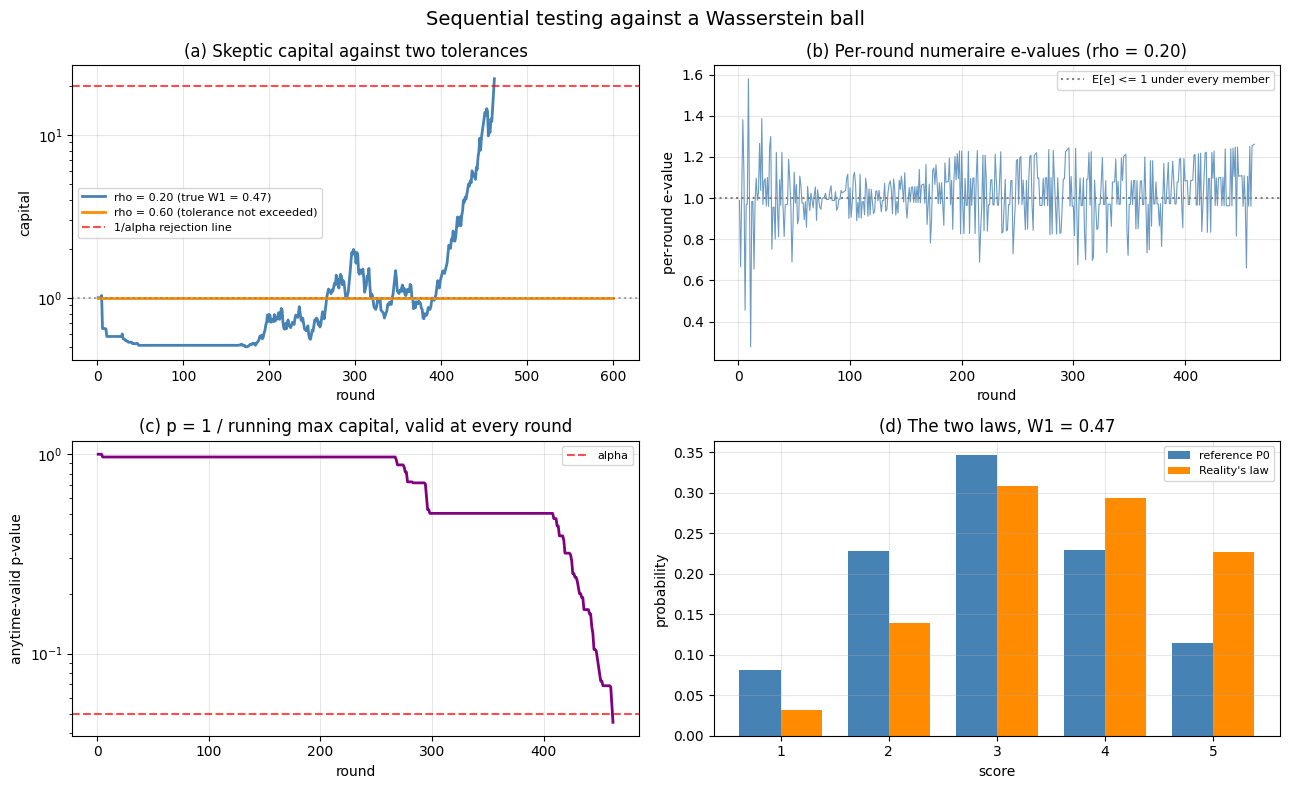

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

df_tight = protocols[0.20].get_history_df()
df_loose = protocols[0.60].get_history_df()

ax = axes[0, 0]
ax.plot(df_tight['step'], df_tight['e_process_value'], lw=2, color='steelblue',
        label=f'rho = 0.20 (true W1 = {true_w1:.2f})')
ax.plot(df_loose['step'], df_loose['e_process_value'], lw=2, color='darkorange',
        label='rho = 0.60 (tolerance not exceeded)')
ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='1/alpha rejection line')
ax.axhline(1.0, color='grey', ls=':', alpha=0.7)
ax.set_yscale('log'); ax.set_xlabel('round'); ax.set_ylabel('capital')
ax.set_title('(a) Skeptic capital against two tolerances')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(df_tight['step'], df_tight['e_value'], lw=0.8, color='steelblue', alpha=0.8)
ax.axhline(1.0, color='grey', ls=':', label='E[e] <= 1 under every member')
ax.set_xlabel('round'); ax.set_ylabel('per-round e-value')
ax.set_title('(b) Per-round numeraire e-values (rho = 0.20)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(df_tight['step'], df_tight['p_value'], lw=2, color='purple')
ax.axhline(ALPHA, color='red', ls='--', alpha=0.7, label='alpha')
ax.set_yscale('log'); ax.set_xlabel('round'); ax.set_ylabel('anytime-valid p-value')
ax.set_title('(c) p = 1 / running max capital, valid at every round')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
width = 0.38
ax.bar(scores - width / 2, p0, width, label='reference P0', color='steelblue')
ax.bar(scores + width / 2, reality, width, label="Reality's law", color='darkorange')
ax.set_xlabel('score'); ax.set_ylabel('probability')
ax.set_title(f'(d) The two laws, W1 = {true_w1:.2f}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Sequential testing against a Wasserstein ball', fontsize=14)
plt.tight_layout()
plt.show()

# 3. An Anytime-Valid Lower Bound On the Size of the Drift

Rejecting "the drift is at most rho" for one rho is a test. Doing it for a grid of
radii simultaneously is an **estimate**: the smallest radius still standing is an
anytime-valid lower confidence bound on W1(Reality, P0), valid at every round and
under optional stopping.

`WassersteinDistanceSequence` runs one `EProcess` per radius, all driven by the same
`EProcessUpdater`, and shares a single Kantorovich potential across the grid so the
per-round cost is one LP rather than one per radius. The bound is conservative by at
most one grid step.

true W1                      : 0.473
lower bound after 200 rounds : 0.30
lower bound after 400 rounds : 0.40
lower bound after 800 rounds : 0.40
radii ruled out so far       : 8 of 17


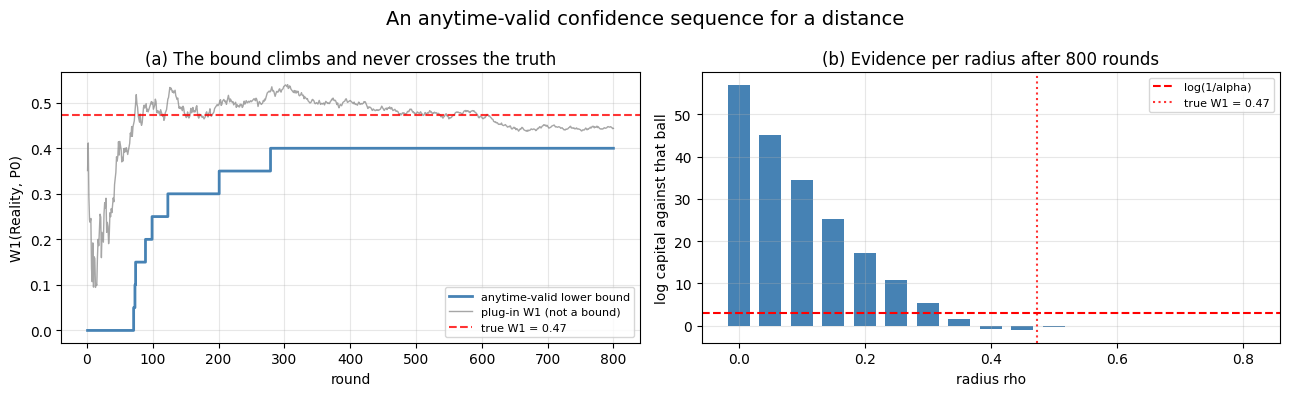

In [5]:
radii = np.linspace(0.0, 0.8, 17)      # grid step 0.05
sequence = WassersteinDistanceSequence(p0, cost, radii=radii, significance_level=ALPHA)

rng = np.random.default_rng(3)
lower_bounds, estimates = [], []

for t in range(800):
    step = sequence.update(int(rng.choice(5, p=reality)))
    lower_bounds.append(step.lower_bound)
    estimates.append(step.wasserstein_estimate)

print(f"true W1                      : {true_w1:.3f}")
print(f"lower bound after 200 rounds : {lower_bounds[199]:.2f}")
print(f"lower bound after 400 rounds : {lower_bounds[399]:.2f}")
print(f"lower bound after 800 rounds : {lower_bounds[-1]:.2f}")
print(f"radii ruled out so far       : {len(step.rejected_radii)} of {len(radii)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.step(range(1, 801), lower_bounds, where='post', lw=2, color='steelblue',
        label='anytime-valid lower bound')
ax.plot(range(1, 801), estimates, lw=1, color='grey', alpha=0.7,
        label='plug-in W1 (not a bound)')
ax.axhline(true_w1, color='red', ls='--', alpha=0.8, label=f'true W1 = {true_w1:.2f}')
ax.set_xlabel('round'); ax.set_ylabel('W1(Reality, P0)')
ax.set_title('(a) The bound climbs and never crosses the truth')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.bar(radii, np.array(step.log_e_processes), width=0.035, color='steelblue')
ax.axhline(np.log(1 / ALPHA), color='red', ls='--', label='log(1/alpha)')
ax.axvline(true_w1, color='red', ls=':', alpha=0.8, label=f'true W1 = {true_w1:.2f}')
ax.set_xlabel('radius rho'); ax.set_ylabel('log capital against that ball')
ax.set_title('(b) Evidence per radius after 800 rounds')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('An anytime-valid confidence sequence for a distance', fontsize=14)
plt.tight_layout()
plt.show()

# 4. Contamination Neighbourhoods: Valid Under Corrupted Records

Test H0: Reality = (1 - eps) P0 + eps Q for some arbitrary Q vs H1: it is not.

Every real data pipeline has a few percent of records that are wrong: mislabelled,
duplicated, entered by hand, emitted by a retry storm. A point null against P0 will
eventually reject because of those records alone, which is a false alarm about the
pipeline rather than a discovery about the process.

The contamination null builds the slack in. `ContaminationNull` computes the support
function in closed form and the numeraire by a one-dimensional KKT search, recovering the
clipped likelihood ratio of the Huber-Strassen (1973) least-favourable pair.

**The corruption is actually injected here.** In each round, with probability `epsilon`
the recorded value is replaced by an arbitrary one, exactly as a mis-scan or a bad retry
would do. That is the whole point: a point-null test would eventually fire on those
records alone, and the demonstration is worthless unless they are really present.

In [6]:
nominal = np.array([0.90, 0.07, 0.025, 0.005])   # 4 quality grades under the stated process
epsilon = 0.03                                   # up to 3% of records may be anything

null = ContaminationNull(nominal, epsilon)


def stream_with_corruption(process, corruption, rng):
    """One recorded value: usually the process, occasionally an arbitrary bad record."""
    if rng.random() < corruption:
        return int(rng.integers(0, len(process)))     # mis-scanned: any grade at all
    return int(rng.choice(len(process), p=process))


cases = {
    "process on spec": nominal,
    "process degraded": np.array([0.80, 0.12, 0.05, 0.03]),
}

runs = {}
for name, truth in cases.items():
    rng = np.random.default_rng(21)
    protocol = BettingProtocol(UpperExpectationSkeptic(null), ADAPTIVE)
    stop = None
    for t in range(4000):
        if protocol.update(stream_with_corruption(truth, epsilon, rng)).reject_null:
            stop = t + 1
            break
    runs[name] = protocol
    summary = protocol.get_summary()
    if stop:
        print(f"{name:18s}: rejected at record {stop:5d}  (max capital {summary['max_e_process']:.1f})")
    else:
        print(f"{name:18s}: no rejection in {protocol.step} records "
              f"(max capital {summary['max_e_process']:.3f})")

print()
for name, truth in cases.items():
    stops = []
    for world in range(10):
        rng = np.random.default_rng(900 + world)
        proto = BettingProtocol(UpperExpectationSkeptic(null), ADAPTIVE)
        stop = None
        for t in range(4000):
            if proto.update(stream_with_corruption(truth, epsilon, rng)).reject_null:
                stop = t + 1
                break
        stops.append(stop)
    detected = [s for s in stops if s is not None]
    median = np.median(detected) if detected else float('nan')
    print(f"10 worlds, {name:18s}: rejected in {len(detected)}/10, median record {median:.0f}")

print()
print("3% of every stream above really is corrupt. The on-spec process is still never")
print("flagged, because that slack is part of the hypothesis - so an alarm means the")
print("process moved, not that the scanner slipped.")

process on spec   : no rejection in 4000 records (max capital 1.000)
process degraded  : rejected at record   502  (max capital 20.2)



10 worlds, process on spec   : rejected in 0/10, median record nan


10 worlds, process degraded  : rejected in 10/10, median record 92

3% of every stream above really is corrupt. The on-spec process is still never
flagged, because that slack is part of the hypothesis - so an alarm means the
process moved, not that the scanner slipped.


# 5. Polytope Nulls: Still a Mixture of Known Regimes?

Test H0: Reality is in conv{P_1, ..., P_V} vs H1: it is outside the hull.

Operational systems are rarely stationary and rarely need to be. Traffic is a mixture
of weekday and weekend, promo and non-promo, and none of those is an anomaly. The
useful question is whether the current stream is still explained by *some* mixture of
regimes that have already been characterised.

`PolytopeNull` gets the support function for free (the maximum over vertices) and
computes the reverse information projection by Csiszar-Tusnady alternating minimisation,
giving the numeraire as the ratio q / p*, where p* is the I-projection of Skeptic's
belief onto the hull.

Reality under the null is deliberately non-stationary here: a fresh, randomly drawn blend
of the three regimes every single round. That is harder than a fixed mixture and it is
what operational data look like - and the null still covers it, because the hull contains
every blend.

Against that we put two shocks of the same kind and different size, both of which move a
fraction of customers one engagement band worse. Both are genuinely outside the hull. The
reverse information projection tells us in advance roughly how many rounds each one needs,
and the test behaves accordingly - which is the point. *Outside the null* and *detectable
within your horizon* are different properties, and only the second one pays the bills.

In [7]:
# Four observable states, three regimes already characterised.
regimes = np.array([
    [0.55, 0.25, 0.15, 0.05],     # regime A
    [0.35, 0.35, 0.22, 0.08],     # regime B
    [0.60, 0.22, 0.13, 0.05],     # regime C
])
null = PolytopeNull(regimes)


def degrade(law, fraction):
    """A shock that moves `fraction` of each state's mass one step worse."""
    moved = law * fraction
    shifted = law - moved
    shifted[1:] += moved[:-1]
    shifted[-1] += moved[-1]
    return shifted


# Reality under H0: every round the population is *some* blend of the three regimes, and
# the blend itself drifts. The null covers all of them, so none of this is an anomaly.
# Reality under H1: an unmodelled shock moves a fraction of customers one band worse.
mild_shock = degrade(regimes[0].copy(), 0.15)
severe_shock = degrade(regimes[0].copy(), 0.35)

print("a drifting blend of regimes is inside the hull by construction")
for label, law in (("mild shock (15%)", mild_shock), ("severe shock (35%)", severe_shock)):
    projection = null.reverse_information_projection(law)
    reachable = np.log(1 / ALPHA) / projection.kl_divergence
    print(f"  {label:20s} {np.round(law, 4)}  inside hull: {null.contains(law)}  "
          f"KL to hull {projection.kl_divergence:.5f}  -> ~{reachable:.0f} rounds to detect")
print()

horizon = 2000
scenarios = {
    "drifting blend of regimes": None,
    "mild shock (15%)": mild_shock,
    "severe shock (35%)": severe_shock,
}
for name, law in scenarios.items():
    rng = np.random.default_rng(31)
    protocol = BettingProtocol(UpperExpectationSkeptic(null), ADAPTIVE)
    stop = None
    for t in range(horizon):
        # under H0 the population is a fresh blend every round
        round_law = rng.dirichlet(np.ones(3)) @ regimes if law is None else law
        if protocol.update(int(rng.choice(4, p=round_law))).reject_null:
            stop = t + 1
            break
    summary = protocol.get_summary()
    verdict = f"rejected at round {stop}" if stop else f"no rejection in {protocol.step} rounds"
    print(f"{name:26s}: {verdict:32s} max capital {summary['max_e_process']:.3g}")

print()
print("The mild shock really is outside the hull, and the test is right not to claim it:")
print("at that distance the evidence needs several thousand rounds, which the horizon")
print("does not provide. Being outside the null is not the same as being detectable.")

a drifting blend of regimes is inside the hull by construction
  mild shock (15%)     [0.4675 0.295  0.165  0.0725]  inside hull: False  KL to hull 0.00091  -> ~3294 rounds to detect
  severe shock (35%)   [0.3575 0.355  0.185  0.1025]  inside hull: False  KL to hull 0.00581  -> ~516 rounds to detect



drifting blend of regimes : no rejection in 2000 rounds      max capital 1


mild shock (15%)          : no rejection in 2000 rounds      max capital 1


severe shock (35%)        : rejected at round 1154           max capital 22

The mild shock really is outside the hull, and the test is right not to claim it:
at that distance the evidence needs several thousand rounds, which the horizon
does not provide. Being outside the null is not the same as being detectable.


# 6. Type-I Error Validity At the Boundary of the Set

The hard case for a composite null is not a law in the middle of the set, it is a law
sitting exactly on the boundary: as close to the alternative as the null permits.
Validity has to hold there too, at every round, under optional stopping.

We put Reality exactly on the surface of the ball, W1(Reality, P0) = rho, and stop at
the first rejection in each of 100 independent runs. Ville's inequality bounds the
rejection rate by alpha for the whole run, not per look.

In [8]:
rho = 0.25
boundary = p0.copy()
boundary[2] -= rho      # move exactly rho units of mass one step to the right
boundary[3] += rho
print(f"W1(boundary law, P0) = "
      f"{WassersteinNull(p0, cost, 0.0).wasserstein_distance(boundary):.3f}  (= rho = {rho})")

n_simulations, n_steps = 100, 120
rejections = 0
final_capital = []

for sim in range(n_simulations):
    rng = np.random.default_rng(1000 + sim)
    protocol = BettingProtocol(UpperExpectationSkeptic(WassersteinNull(p0, cost, rho)), ADAPTIVE)
    rejected = False
    for t in range(n_steps):
        if protocol.update(int(rng.choice(5, p=boundary))).reject_null:
            rejected = True
            break
    rejections += rejected
    final_capital.append(protocol.get_summary()['max_e_process'])

rate = rejections / n_simulations
se = np.sqrt(rate * (1 - rate) / n_simulations) if rate > 0 else np.sqrt(1 / n_simulations) / 2

print(f"\nType-I simulation (Reality on the boundary of the null set)")
print(f"  Simulations:    {n_simulations}")
print(f"  Max rounds:     {n_steps}")
print(f"  Rejections:     {rejections}")
print(f"  Rejection rate: {rate:.3f} +/- {1.96 * se:.3f}")
print(f"  Nominal alpha:  {ALPHA}")
print(f"  Valid:          {rate <= ALPHA + 3 * se}")
print(f"  Median max capital: {np.median(final_capital):.3f}")

W1(boundary law, P0) = 0.250  (= rho = 0.25)



Type-I simulation (Reality on the boundary of the null set)
  Simulations:    100
  Max rounds:     120
  Rejections:     3
  Rejection rate: 0.030 +/- 0.033
  Nominal alpha:  0.05
  Valid:          True
  Median max capital: 1.200


# 7. Real World: Clinical Non-Inferiority On an Adverse-Event Scale

**Scenario:** A phase-III trial compares a new oncology regimen against standard of
care. The endpoint is worst-grade toxicity per patient on the CTCAE scale (grade 0 =
none through grade 4 = life-threatening). The registration question is *not* "are the
toxicity distributions identical" - they never are - but "is the new regimen worse by
more than the pre-specified non-inferiority margin?"

- **Margin:** 0.10 grades of expected worst-grade toxicity, agreed with the regulator
  in the statistical analysis plan and written into the protocol before enrolment.
- **Endpoint:** an ordinal grade, so W1 with ground cost |i - j| is exactly "average
  number of grades of extra toxicity", the quantity the margin is stated in.
- **Null:** every law within 0.10 grades of the control distribution. Not a point null.

**Why sequential testing matters here:**
- A data monitoring committee looks at the accumulating data several times a year.
  Group-sequential alpha spending has to fix the look schedule in advance; an e-process
  is valid at *every* round, so unscheduled safety looks cost nothing.
- If the regimen really is more toxic, patients are being harmed while the trial runs.
  Stopping at the first moment the evidence clears 1/alpha is an ethical requirement,
  not a convenience.
- The margin is part of the hypothesis, so the trial cannot be "won" by an
  irrelevant 0.01-grade difference detected on a very large sample.

**Realistic parameters:** control toxicity is dominated by grades 0-1. The comparable arm
shifts latent severity by 0.05 sigma and the more toxic arm by 0.35 sigma; the resulting
excess toxicity in grades is whatever the CTCAE cutpoints make it, and is printed below
alongside the margin.

comparable arm (latent +0.05) : true excess 0.040 grades (margin 0.1)  ->  no rejection in 3000 patients


more toxic arm (latent +0.35) : true excess 0.308 grades (margin 0.1)  ->  non-inferiority rejected after 182 patients



6 trials, comparable arm (latent +0.05) : stopped in 0/6, median nan patients


6 trials, more toxic arm (latent +0.35) : stopped in 6/6, median 162 patients


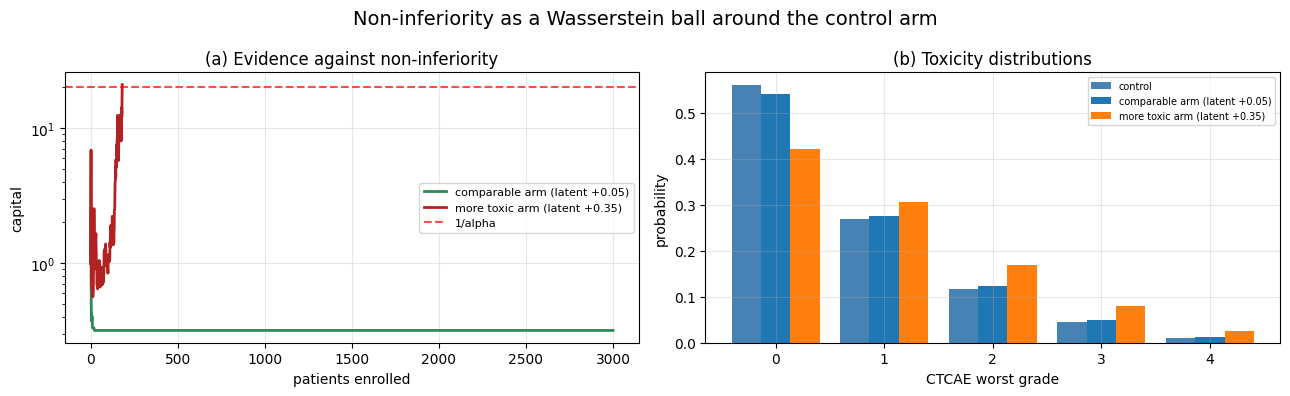

In [9]:
grades = np.arange(5, dtype=float)                       # CTCAE grade 0..4
grade_cost = np.abs(grades[:, None] - grades[None, :])

# Toxicity grades are the observable face of a latent severity, cut by the CTCAE
# definitions. A more toxic regimen shifts that latent severity; the grade distribution
# is a consequence, not a choice.
toxicity_cutpoints = np.array([0.15, 0.95, 1.60, 2.30])


def toxicity_law(latent_shift):
    edges = np.concatenate(([-np.inf], toxicity_cutpoints, [np.inf]))
    return np.diff(norm.cdf(edges - latent_shift))


control_toxicity = toxicity_law(0.0)
margin = 0.10                                            # pre-specified, in grades

arms = {
    "comparable arm (latent +0.05)": toxicity_law(0.05),
    "more toxic arm (latent +0.35)": toxicity_law(0.35),
}

trial_runs = {}
for name, arm in arms.items():
    excess = WassersteinNull(control_toxicity, grade_cost, 0.0).wasserstein_distance(arm)
    rng = np.random.default_rng(7)
    protocol = BettingProtocol(
        UpperExpectationSkeptic(WassersteinNull(control_toxicity, grade_cost, margin)), ADAPTIVE
    )
    stop = None
    for patient in range(3000):
        if protocol.update(int(rng.choice(5, p=arm))).reject_null:
            stop = patient + 1
            break
    trial_runs[name] = protocol
    verdict = (f"non-inferiority rejected after {stop} patients"
               if stop else f"no rejection in {protocol.step} patients")
    print(f"{name:30s}: true excess {excess:.3f} grades (margin {margin})  ->  {verdict}")

print()
for name, arm in arms.items():
    stops = []
    for trial in range(6):
        rng = np.random.default_rng(1500 + trial)
        proto = BettingProtocol(
            UpperExpectationSkeptic(WassersteinNull(control_toxicity, grade_cost, margin)),
            ADAPTIVE,
        )
        stop = None
        for patient in range(3000):
            if proto.update(int(rng.choice(5, p=arm))).reject_null:
                stop = patient + 1
                break
        stops.append(stop)
    detected = [s for s in stops if s is not None]
    median = np.median(detected) if detected else float('nan')
    print(f"6 trials, {name:30s}: stopped in {len(detected)}/6, median {median:.0f} patients")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for name, colour in zip(arms, ('seagreen', 'firebrick')):
    df = trial_runs[name].get_history_df()
    ax.plot(df['step'], df['e_process_value'], lw=2, color=colour, label=name)
ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='1/alpha')
ax.set_yscale('log'); ax.set_xlabel('patients enrolled'); ax.set_ylabel('capital')
ax.set_title('(a) Evidence against non-inferiority')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
width = 0.27
ax.bar(grades - width, control_toxicity, width, label='control', color='steelblue')
for offset, (name, arm) in zip((0, width), arms.items()):
    ax.bar(grades + offset, arm, width, label=name)
ax.set_xlabel('CTCAE worst grade'); ax.set_ylabel('probability')
ax.set_title('(b) Toxicity distributions')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle('Non-inferiority as a Wasserstein ball around the control arm', fontsize=14)
plt.tight_layout()
plt.show()

# 8. Real World: Supplier Quality Under Mislabelled Records

**Scenario:** A contract manufacturer ships components under an agreed quality
distribution across four grades (A, B, C, scrap). Incoming inspection records the
grade of each unit. The receiving plant knows from long experience that about 3% of
inspection records are wrong: units mis-scanned at goods-in, rework not written back,
an operator clearing a jam by re-entering the previous code.

- **Contract distribution:** 90% grade A, 7% grade B, 2.5% grade C, 0.5% scrap.
- **Known corruption:** up to 3% of records may be arbitrary. Not random noise with a
  known law - *arbitrary*, which is what Huber contamination allows.
- **Decision:** trigger a supplier audit, which is expensive and damages the
  relationship, so a false alarm has a real cost.

**Why sequential testing matters here:**
- Inspection arrives continuously; the plant wants an alarm as soon as the evidence
  justifies one, not at a quarterly review.
- A point-null test against the contract distribution is guaranteed to fire eventually
  on the 3% mislabelled records alone. That alarm is about the scanner, not the
  supplier, and it destroys trust in the monitor.
- Building the corruption rate into the null means a rejection is evidence that the
  *process* moved by more than bad records can explain.

**Realistic parameters:** a degraded supplier drifting to 80/12/5/3 is detected in
several hundred inspected units; a compliant supplier is never flagged, even though
3% of its records are genuinely wrong.

compliant supplier  : no audit after  5000 inspected units (max capital 1.000)
degraded supplier   : audit triggered after   236 inspected units



10 quarters, compliant supplier  : audited 0/10, median nan units


10 quarters, degraded supplier   : audited 10/10, median 197 units


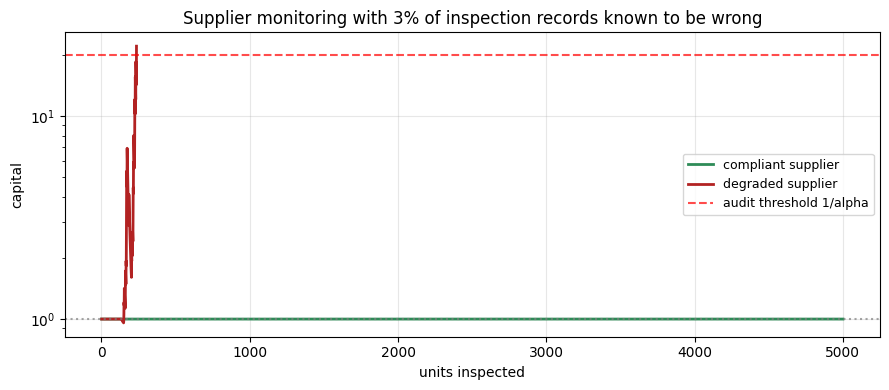

In [10]:
contract = np.array([0.90, 0.07, 0.025, 0.005])      # grades A, B, C, scrap
record_corruption = 0.03                             # known rate of mislabelled records

supplier_null = ContaminationNull(contract, record_corruption)

suppliers = {
    "compliant supplier": contract,
    "degraded supplier":  np.array([0.80, 0.12, 0.05, 0.03]),
}

audit_runs = {}
for name, truth in suppliers.items():
    rng = np.random.default_rng(2024)
    protocol = BettingProtocol(UpperExpectationSkeptic(supplier_null), ADAPTIVE)
    stop = None
    for unit in range(5000):
        # Inspection records really are corrupted at the stated rate.
        if protocol.update(stream_with_corruption(truth, record_corruption, rng)).reject_null:
            stop = unit + 1
            break
    audit_runs[name] = protocol
    if stop:
        print(f"{name:20s}: audit triggered after {stop:5d} inspected units")
    else:
        print(f"{name:20s}: no audit after {protocol.step:5d} inspected units "
              f"(max capital {protocol.get_summary()['max_e_process']:.3f})")

print()
for name, truth in suppliers.items():
    stops = []
    for quarter in range(10):
        rng = np.random.default_rng(3100 + quarter)
        proto = BettingProtocol(UpperExpectationSkeptic(supplier_null), ADAPTIVE)
        stop = None
        for unit in range(5000):
            if proto.update(stream_with_corruption(truth, record_corruption, rng)).reject_null:
                stop = unit + 1
                break
        stops.append(stop)
    detected = [s for s in stops if s is not None]
    median = np.median(detected) if detected else float('nan')
    print(f"10 quarters, {name:20s}: audited {len(detected)}/10, median {median:.0f} units")

fig, ax = plt.subplots(figsize=(9, 4))
for name, colour in zip(suppliers, ('seagreen', 'firebrick')):
    df = audit_runs[name].get_history_df()
    ax.plot(df['step'], df['e_process_value'], lw=2, color=colour, label=name)
ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='audit threshold 1/alpha')
ax.axhline(1.0, color='grey', ls=':', alpha=0.7)
ax.set_yscale('log'); ax.set_xlabel('units inspected'); ax.set_ylabel('capital')
ax.set_title('Supplier monitoring with 3% of inspection records known to be wrong')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Real World: LLM Judge-Score Regression Gate In Production

**Scenario:** A product team ships a new model version behind a canary. Every canary
response is scored 1-5 by an LLM judge against a rubric. The release gate has to
answer "has quality regressed by more than we are willing to ship?" while the canary
is running, on a stream that arrives continuously.

- **Reference:** the judge-score distribution of the incumbent version, measured on
  the same traffic mix.
- **Tolerance:** the team will ship a regression of up to 0.10 judge points, because
  the new version is cheaper and faster. Anything larger blocks the release.
- **What the gate needs:** not just a reject/accept flag but a defensible *number* -
  "with anytime-valid 95% confidence the regression is at least X judge points" - to
  put in the release review.

**Why sequential testing matters here:**
- The canary is watched continuously by an automated gate; a fixed-sample test would
  have to pre-commit to a sample size and ignore everything before it.
- Rolling back early saves real user harm; every extra hour of canary traffic on a
  regressed model is impressions the team cannot get back.
- Judge scores are ordinal and heavily tied. W1 on the 1-5 scale is exactly "average
  judge points lost", which is the unit the product manager reasons in.

**Realistic parameters:** the candidate model's latent response quality is 0.35 sigma
below the incumbent's, which the rubric turns into a regression of roughly a third of a
judge point. The gate reports the certified lower bound as it climbs.

incumbent mean judge score : 3.799
candidate mean judge score : 3.425
true regression            : 0.374 judge points (ship tolerance 0.1)


release blocked after 343 judged responses
certified lower bound after 1,500 responses: 0.30 judge points


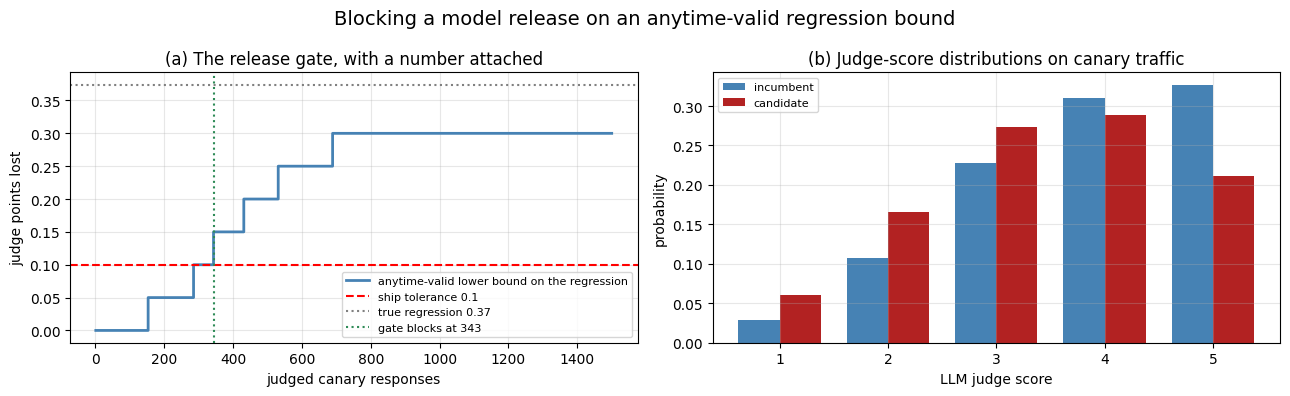

In [11]:
judge_scores = np.arange(1, 6, dtype=float)
judge_cost = np.abs(judge_scores[:, None] - judge_scores[None, :])

# Judge scores are a latent response quality cut into five rubric bands; a weaker model
# shifts that latent quality down. The score distribution follows from the shift.
judge_cutpoints = np.array([-1.90, -1.10, -0.35, 0.45])


def judge_law(latent_shift):
    edges = np.concatenate(([-np.inf], judge_cutpoints, [np.inf]))
    return np.diff(norm.cdf(edges - latent_shift))


incumbent = judge_law(0.0)
candidate = judge_law(-0.35)      # the candidate model is 0.35 sigma weaker
ship_tolerance = 0.10

true_regression = WassersteinNull(incumbent, judge_cost, 0.0).wasserstein_distance(candidate)
print(f"incumbent mean judge score : {float(incumbent @ judge_scores):.3f}")
print(f"candidate mean judge score : {float(candidate @ judge_scores):.3f}")
print(f"true regression            : {true_regression:.3f} judge points "
      f"(ship tolerance {ship_tolerance})")

gate = WassersteinDistanceSequence(
    incumbent, judge_cost, radii=np.linspace(0.0, 0.6, 13), significance_level=ALPHA
)

rng = np.random.default_rng(9)
bounds, blocked_at = [], None

for response in range(1500):
    step = gate.update(int(rng.choice(5, p=candidate)))
    bounds.append(step.lower_bound)
    if blocked_at is None and step.lower_bound > ship_tolerance:
        blocked_at = response + 1

print(f"release blocked after {blocked_at} judged responses")
print(f"certified lower bound after 1,500 responses: {bounds[-1]:.2f} judge points")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.step(range(1, 1501), bounds, where='post', lw=2, color='steelblue',
        label='anytime-valid lower bound on the regression')
ax.axhline(ship_tolerance, color='red', ls='--', label=f'ship tolerance {ship_tolerance}')
ax.axhline(true_regression, color='grey', ls=':', label=f'true regression {true_regression:.2f}')
if blocked_at:
    ax.axvline(blocked_at, color='seagreen', ls=':', label=f'gate blocks at {blocked_at}')
ax.set_xlabel('judged canary responses'); ax.set_ylabel('judge points lost')
ax.set_title('(a) The release gate, with a number attached')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
width = 0.38
ax.bar(judge_scores - width / 2, incumbent, width, label='incumbent', color='steelblue')
ax.bar(judge_scores + width / 2, candidate, width, label='candidate', color='firebrick')
ax.set_xlabel('LLM judge score'); ax.set_ylabel('probability')
ax.set_title('(b) Judge-score distributions on canary traffic')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Blocking a model release on an anytime-valid regression bound', fontsize=14)
plt.tight_layout()
plt.show()

# 10. Real World: A Prediction Market Quoting a Bid-Ask Spread

**Scenario:** A market maker quotes a binary event as a bid-ask spread rather than a
single price, because a spread is what a real book looks like: the maker will buy at
the bid and sell at the ask, and any probability in between is consistent with the
quote. A trader wants to know whether the market is *wrong*, not whether it differs
from one arbitrary point inside its own spread.

- **Forecaster's announcement changes every round.** The spread moves with the book.
  `BettingProtocol.update(outcome, announcement=...)` accepts a fresh null each round,
  and validity holds under any adapted choice of a member from each round's set.
- **The null:** {q : bid <= q(yes) <= ask}, a two-vertex polytope on {no, yes}.
- **Skeptic's alternative:** a fixed belief about the true probability, so the capital
  process is exactly the trader's bankroll under a Kelly-style strategy.

**Why sequential testing matters here:**
- Events resolve one at a time over weeks. The trader wants to know when the evidence
  of mispricing is decisive, not after a pre-set number of contracts.
- The capital process *is* the money: Skeptic's wealth is the payoff of the implied
  betting strategy, so "reject at 1/alpha" and "turned $1 into $20" are the same event.
- Testing against the whole spread means the trader cannot fool themselves by picking
  the most favourable point inside the quote.

**Realistic parameters:** the true probability is 0.72. The maker's mid is a
mean-reverting random walk around an anchor, quoted with a 3.5-point half-spread, so the
null set moves every round. One maker is anchored at 0.58, the other at the truth.

market underprices the event  : mispricing proven after 146 resolved events ($1 -> $24.15)


market brackets the truth     : no mispricing in 600 events ($1 -> $1.69)


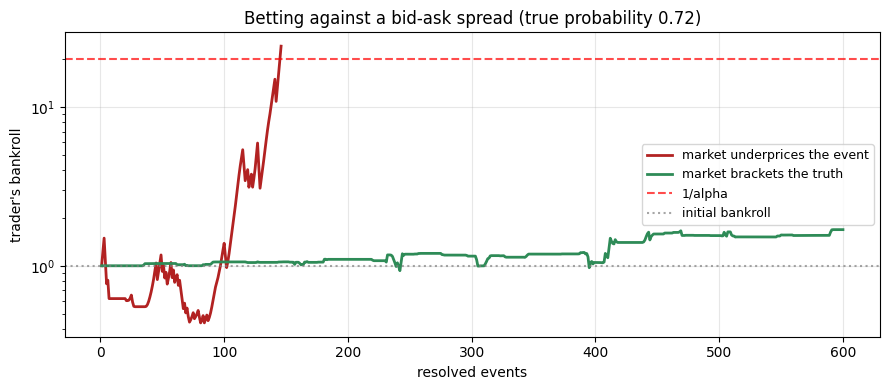

In [12]:
true_probability = 0.72          # Reality's chance of "yes"

markets = {
    "market underprices the event": 0.58,   # the maker's mid, anchored away from the truth
    "market brackets the truth":    0.72,   # the maker's mid, anchored on the truth
}
half_spread = 0.035              # the maker will buy at mid - h and sell at mid + h

market_runs = {}
for name, anchor in markets.items():
    rng = np.random.default_rng(10)
    # Skeptic holds a fixed view of the probability; the null set moves each round.
    skeptic = UpperExpectationSkeptic(
        config=UpperExpectationConfig(alternative=[1 - true_probability, true_probability])
    )
    protocol = BettingProtocol(skeptic, ADAPTIVE)
    stop = None
    mid = anchor

    for event in range(600):
        # The book wanders: a mean-reverting random walk around the maker's anchor.
        mid = float(np.clip(mid + 0.15 * (anchor - mid) + 0.015 * rng.standard_normal(),
                            0.02, 0.98))
        quote_bid = float(np.clip(mid - half_spread, 0.01, 0.97))
        quote_ask = float(np.clip(mid + half_spread, quote_bid + 0.01, 0.99))
        spread = PolytopeNull(np.array([[1 - quote_bid, quote_bid],
                                        [1 - quote_ask, quote_ask]]))

        outcome = int(rng.random() < true_probability)
        if protocol.update(outcome, announcement=spread).reject_null:
            stop = event + 1
            break

    market_runs[name] = protocol
    if stop:
        print(f"{name:30s}: mispricing proven after {stop} resolved events "
              f"($1 -> ${protocol.get_summary()['max_e_process']:.2f})")
    else:
        print(f"{name:30s}: no mispricing in {protocol.step} events "
              f"($1 -> ${protocol.get_summary()['max_e_process']:.2f})")

fig, ax = plt.subplots(figsize=(9, 4))
for name, colour in zip(markets, ('firebrick', 'seagreen')):
    df = market_runs[name].get_history_df()
    ax.plot(df['step'], df['e_process_value'], lw=2, color=colour, label=name)
ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='1/alpha')
ax.axhline(1.0, color='grey', ls=':', alpha=0.7, label='initial bankroll')
ax.set_yscale('log'); ax.set_xlabel('resolved events'); ax.set_ylabel("trader's bankroll")
ax.set_title(f'Betting against a bid-ask spread (true probability {true_probability})')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 11. Physics: Ruling Out *Every* Local-Realist Model At Once

**Scenario:** A Bell test. Two separated detectors measure entangled particles; each
round draws settings (a, b) and records outcomes (x, y). The null hypothesis is not a
distribution, it is a *theory*: local realism, i.e. the outcomes were determined by
shared hidden variables and each detector's result does not depend on the distant
setting. Every such model gives a joint law in the convex hull of the 16 local
deterministic strategies.

This is the natural home of upper-expectation testing. There is no single null law to
test against, and the traditional analysis - estimate the CHSH value S, quote
"violation by N sigma" - assumes i.i.d. trials and a fixed sample size, neither of
which a real experiment with drifting detectors satisfies.

`CHSHLocalRealismNull` builds the 16 vertices, so the numeraire against the hull is
the prediction-based-ratio analysis of Zhang, Glancy & Knill (2011), and its growth
rate is the statistical strength of van Dam, Gill & Grunwald (2005). Skeptic's capital
is a bona fide e-process: an experimenter may stop whenever the evidence is decisive
and the guarantee still holds.

CHSH value S of the quantum law : -2.8284   (Tsirelson bound -2.8284)
local realism allows            : |S| <= 2
quantum law inside the hull     : False
optimal growth rate             : 0.03207 nats per trial
trials to 1/alpha (asymptotic)  : 93

quantum source      : local realism rejected after 155 trials


best classical fake : never rejected in 4000 trials (max capital 2.885)


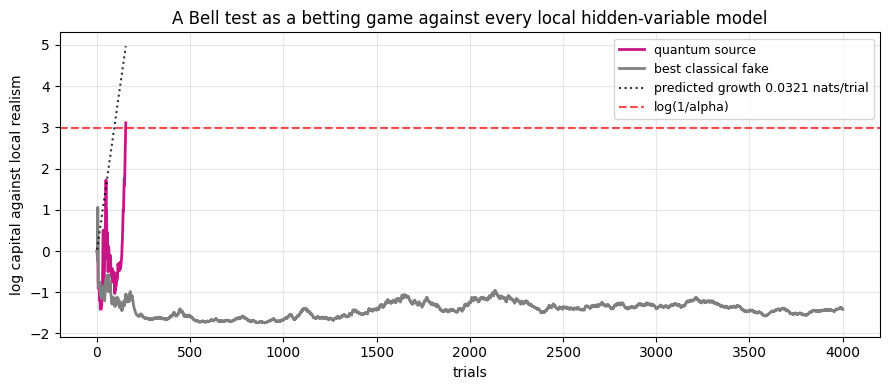

In [13]:
null = CHSHLocalRealismNull()                   # uniform random settings
quantum = null.singlet_distribution()           # singlet state at the optimal angles

print(f"CHSH value S of the quantum law : {null.chsh_value(quantum):.4f}"
      f"   (Tsirelson bound {-2 * np.sqrt(2):.4f})")
print(f"local realism allows            : |S| <= 2")
print(f"quantum law inside the hull     : {null.contains(quantum)}")

e_star = null.optimal_e_variable(quantum)
growth = float(quantum @ np.log(e_star))
print(f"optimal growth rate             : {growth:.5f} nats per trial")
print(f"trials to 1/alpha (asymptotic)  : {np.log(1 / ALPHA) / growth:.0f}")
print()

experiments = {
    "quantum source": quantum,
    "best classical fake": null.worst_case_member(e_star),
}

bell_runs = {}
for name, law in experiments.items():
    rng = np.random.default_rng(41)
    protocol = BettingProtocol(UpperExpectationSkeptic(null), ADAPTIVE)
    stop = None
    for trial in range(4000):
        if protocol.update(int(rng.choice(16, p=law))).reject_null:
            stop = trial + 1
            break
    bell_runs[name] = protocol
    if stop:
        print(f"{name:20s}: local realism rejected after {stop} trials")
    else:
        print(f"{name:20s}: never rejected in {protocol.step} trials "
              f"(max capital {protocol.get_summary()['max_e_process']:.3f})")

fig, ax = plt.subplots(figsize=(9, 4))
for name, colour in zip(experiments, ('mediumvioletred', 'grey')):
    df = bell_runs[name].get_history_df()
    ax.plot(df['step'], df['log_e_process'], lw=2, color=colour, label=name)
steps = np.arange(1, bell_runs['quantum source'].step + 1)
ax.plot(steps, growth * steps, ls=':', color='black', alpha=0.8,
        label=f'predicted growth {growth:.4f} nats/trial')
ax.axhline(np.log(1 / ALPHA), color='red', ls='--', alpha=0.7, label='log(1/alpha)')
ax.set_xlabel('trials'); ax.set_ylabel('log capital against local realism')
ax.set_title('A Bell test as a betting game against every local hidden-variable model')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 12. How It Works: Support Functions, the Numeraire, and the Certificate

Forecaster announces a closed convex set $\mathcal{P}$ of laws on a finite outcome
space. Skeptic buys a payoff $e \geq 0$. The payoff is a valid e-variable for the
composite null iff

$$\sigma_{\mathcal{P}}(e) \;=\; \sup_{P \in \mathcal{P}} \mathbb{E}_P[e] \;\leq\; 1 ,$$

the **support function** of $\mathcal{P}$ at $e$. Each null class computes
$\sigma_{\mathcal{P}}$ exactly, which is what makes `certify(e) = e / \max(1, \sigma)`
a certificate rather than a hope.

| Null class | Support function | Numeraire |
|---|---|---|
| `ContaminationNull` | $(1-\varepsilon)\langle p_0, e\rangle + \varepsilon \max_i e_i$ | clipped LR, Huber & Strassen (1973) |
| `WassersteinNull` | transport LP | witness from the dual (Kantorovich) potential |
| `PolytopeNull` | $\max_v \langle P_v, e\rangle$ | $q / p^*$, $p^*$ = RIPr by Csiszar-Tusnady EM |
| `CHSHLocalRealismNull` | max over 16 local strategies | Zhang, Glancy & Knill (2011) |

**The numeraire.** Among all $e$ with $\sigma_{\mathcal{P}}(e) \le 1$, there is a
unique maximiser of $\mathbb{E}_q[\log e]$ (Larsson, Ramdas & Ruf, Def. 2.1 and
Thm. 2.6). By their Theorem 3.6 it coincides with the GRO e-variable of Grunwald, de
Heide & Koolen (Thm. 1), and it equals $q / p^*$ where $p^*$ is the reverse
information projection of $q$ onto $\mathcal{P}$. Its growth rate

$$\mathbb{E}_q[\log e^\star] \;=\; \mathrm{KL}(q \,\|\, p^\star)$$

is the nats of evidence available per round, and $\log(1/\alpha)$ divided by it is the
asymptotic number of rounds to rejection - the number printed in sections 1 and 11.

**The protocol.** Each round, `BettingProtocol` asks Skeptic for a bet that is
$\mathcal{F}_{t-1}$-measurable, validates that the emitted e-value is finite and
nonnegative *before* touching any state, hands it to `EProcessUpdater` for temporal
betting, and applies Ville's inequality
$\mathbb{P}(\exists t: M_t \geq 1/\alpha) \leq \alpha$. Skeptic's belief $q_{t-1}$ is
the Krichevsky-Trofimov plug-in from the past, so the filtration is respected and the
whole capital process is an e-process for the composite null (Shafer & Vovk 2019,
Ch. 1 and 8).

**What this does not give you.** The outcome space must be finite: every construction
here is a linear or convex programme over $K$ atoms. Cost per round is $O(K)$
root-finds for contamination, one LP with $K^2$ variables for Wasserstein, one EM for
a polytope. These are intended for small $K$ - scores, grades, quality bands,
detector outcomes - not for high-dimensional continuous data.